# Customer Segmentation: A Key to Unlocking Business Growth and Success 
**Authors**: Pedro Ambar, Inês Chainho  
**Date**: April 2026

This notebook walks through the full pipeline for segmenting a retail store’s customer base. The goal is to enable more targeted marketing strategies by understanding customer behavior.

### Project Steps:
1. Data Loading and Inspection  
2. Preprocessing and Feature Engineering  
3. Exploratory Data Analysis  
4. Clustering and Segmentation  
5. Cluster Profiling  
6. Market Basket Analysis  
7. Exporting Results

## Environment Setup and EDA

We begin by importing all necessary libraries and explore and analyze our data.

In [65]:
# Step 1.1 — Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Step 1.2 — Load customer_info dataset
c_info = pd.read_csv("customer_info.csv")
c_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [67]:
# Step 1.3 — Initial inspection of customer_info
display(c_info.head())
display(c_info.describe().T)

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


In [68]:
# Step 1.4 — Inspect categorical variables
categorical_cols = ["customer_name", "customer_gender", "customer_birthdate"]
display(c_info[categorical_cols].describe())

,customer_name,customer_gender,customer_birthdate
count,33038,33038,32873
unique,32543,2,32852
top,Susan Smith,female,11/03/1998 06:10 PM
freq,5,16577,2


In [69]:
# Step 1.5 — Summary of categorical variables
print("Gender distribution:")
display(c_info["customer_gender"].value_counts(dropna=False))

print("Number of unique customer names:", c_info["customer_name"].nunique())
print("Number of unique birthdates:", c_info["customer_birthdate"].nunique())

Gender distribution:


customer_gender
female    16577
male      16461
Name: count, dtype: int64

Number of unique customer names: 32543
Number of unique birthdates: 32852


In [70]:
# Step 1.6 — Load customer_basket dataset
customer_basket = pd.read_csv("customer_basket.csv")

customer_basket.info()
display(customer_basket.head())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 14.7 MB


,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [71]:
# Step 1.7 — Check dataset dimensions
print("Customer info shape:", c_info.shape)
print("Customer basket shape:", customer_basket.shape)

Customer info shape: (33038, 25)
Customer basket shape: (100000, 3)


In [72]:
# Step 1.8 — Check missing values
print("Missing values in customer_info:")
display(c_info.isnull().sum())

print("Missing values in customer_basket:")
display(customer_basket.isnull().sum())

Missing values in customer_info:


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

Missing values in customer_basket:


invoice_id       0
list_of_goods    0
customer_id      0
dtype: int64

In [73]:
# Step 1.9 — Check duplicated rows
print("Duplicated rows in customer_info:", c_info.duplicated().sum())
print("Duplicated rows in customer_basket:", customer_basket.duplicated().sum())

print("Duplicated customer_id in customer_info:", c_info["customer_id"].duplicated().sum())

Duplicated rows in customer_info: 0
Duplicated rows in customer_basket: 0
Duplicated customer_id in customer_info: 0


In [74]:
# Step 1.10 — Check connection between customer_info and customer_basket
basket_customers = set(customer_basket["customer_id"])
info_customers = set(c_info["customer_id"])

customers_only_in_basket = basket_customers - info_customers
customers_only_in_info = info_customers - basket_customers

print("Customers in basket but not in customer_info:", len(customers_only_in_basket))
print("Customers in customer_info but not in basket:", len(customers_only_in_info))

Customers in basket but not in customer_info: 0
Customers in customer_info but not in basket: 4911


### Step 1.11 — Data loading and inspection interpretation

The initial inspection confirms that both datasets were successfully loaded. The `customer_info` dataset contains 33,038 customers and 25 columns, while the `customer_basket` dataset contains 100,000 transactions and 3 columns. The two datasets can be connected through the `customer_id` variable.

The `customer_info` dataset contains missing values in several demographic and spending-related variables, such as `customer_birthdate`, `kids_home`, `teens_home`, `number_complaints`, some lifetime spending categories and `percentage_of_products_bought_promotion`. The `loyalty_card_number` variable also contains many missing values, which likely indicates customers without a loyalty card rather than an error. These missing values will be handled during the preprocessing stage. In contrast, the `customer_basket` dataset does not contain missing values.

No duplicated rows were found in either dataset, and `customer_id` is unique in the `customer_info` dataset. This confirms that `customer_info` can be treated as the customer-level dataset, with one row per customer.

The connection check between datasets shows that all customers appearing in `customer_basket` are also present in `customer_info`. However, 4,911 customers appear in `customer_info` but not in `customer_basket`. This is acceptable because the basket dataset contains a sample of transactions, while the final output should still include every customer from `customer_info`.

The initial descriptive statistics also suggest some data quality issues that should be reviewed in preprocessing, such as future values in `year_first_transaction` and negative values in `percentage_of_products_bought_promotion`. Overall, Step 1 confirms that the datasets are correctly loaded and ready for cleaning, feature engineering and exploratory analysis.

## 2. Preprocessing and Feature Engineering

We clean and transform the data:
- Check for duplicates
- Convert birth date to age
- Remove irrelevant columns
- Fill missing values
- Create additional customer-level features for segmentation 

In [ ]:
# Step 2.1 — Define preprocessing and feature engineering function
def preprocess_customer_info(df):
    """
    Cleans customer_info and creates additional features for customer segmentation.
    """
    
    df_clean = df.copy()
    
    df_clean = df_clean.drop_duplicates()
    
    df_clean["customer_birthdate"] = pd.to_datetime(
        df_clean["customer_birthdate"],
        format="%m/%d/%Y %I:%M %p",
        errors="coerce"
    )
    
    reference_date = pd.Timestamp("2026-04-01")
    df_clean["age"] = (
        (reference_date - df_clean["customer_birthdate"]).dt.days / 365.25
    )
    
    df_clean.loc[(df_clean["age"] < 16) | (df_clean["age"] > 100), "age"] = np.nan

    df_clean["has_loyalty_card"] = df_clean["loyalty_card_number"].notna().astype(int)
    
    df_clean["is_female"] = (df_clean["customer_gender"] == "female").astype(int)
    
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    numeric_cols = df_clean.select_dtypes(include=["number"]).columns
    
    for col in numeric_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    spend_cols = [
        "lifetime_spend_groceries",
        "lifetime_spend_electronics",
        "lifetime_spend_vegetables",
        "lifetime_spend_nonalcohol_drinks",
        "lifetime_spend_alcohol_drinks",
        "lifetime_spend_meat",
        "lifetime_spend_fish",
        "lifetime_spend_hygiene",
        "lifetime_spend_videogames",
        "lifetime_spend_petfood"
    ]
    
    df_clean["total_lifetime_spend"] = df_clean[spend_cols].sum(axis=1)
    
    df_clean["food_spend"] = df_clean[
        [
            "lifetime_spend_groceries",
            "lifetime_spend_vegetables",
            "lifetime_spend_meat",
            "lifetime_spend_fish"
        ]
    ].sum(axis=1)
    
    df_clean["drinks_spend"] = df_clean[
        [
            "lifetime_spend_nonalcohol_drinks",
            "lifetime_spend_alcohol_drinks"
        ]
    ].sum(axis=1)
    
    df_clean["tech_entertainment_spend"] = df_clean[
        [
            "lifetime_spend_electronics",
            "lifetime_spend_videogames"
        ]
    ].sum(axis=1)
    
    df_clean["household_pet_spend"] = df_clean[
        [
            "lifetime_spend_hygiene",
            "lifetime_spend_petfood"
        ]
    ].sum(axis=1)
    
    df_clean["children_home"] = df_clean["kids_home"] + df_clean["teens_home"]

    reference_year = 2026

    df_clean.loc[
        df_clean["year_first_transaction"] > reference_year,
        "year_first_transaction"
    ] = np.nan

    df_clean["year_first_transaction"] = df_clean["year_first_transaction"].fillna(
        df_clean["year_first_transaction"].median()
    )

    df_clean["customer_tenure"] = reference_year - df_clean["year_first_transaction"]
    
    
    df_clean["spend_per_distinct_product"] = (
        df_clean["total_lifetime_spend"] /
        df_clean["lifetime_total_distinct_products"].replace(0, np.nan)
    )
    
    df_clean["food_spend_share"] = (
        df_clean["food_spend"] /
        df_clean["total_lifetime_spend"].replace(0, np.nan)
    )
    
    df_clean["tech_entertainment_share"] = (
        df_clean["tech_entertainment_spend"] /
        df_clean["total_lifetime_spend"].replace(0, np.nan)
    )
    
    df_clean["household_pet_share"] = (
        df_clean["household_pet_spend"] /
        df_clean["total_lifetime_spend"].replace(0, np.nan)
    )
    
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    numeric_cols = df_clean.select_dtypes(include=["number"]).columns
    
    for col in numeric_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    cols_to_drop = [
        "customer_name",
        "customer_birthdate",
        "customer_gender",
        "loyalty_card_number"
    ]
    
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    return df_clean

In [ ]:
# Step 2.2 — Apply preprocessing function
clean_df = preprocess_customer_info(c_info)

clean_df.info()
clean_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 35 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   kids_home                                33038 non-null  float64
 2   teens_home                               33038 non-null  float64
 3   number_complaints                        33038 non-null  float64
 4   distinct_stores_visited                  33038 non-null  float64
 5   lifetime_spend_groceries                 33038 non-null  float64
 6   lifetime_spend_electronics               33038 non-null  float64
 7   typical_hour                             33038 non-null  float64
 8   lifetime_spend_vegetables                33038 non-null  float64
 9   lifetime_spend_nonalcohol_drinks         33038 non-null  float64
 10  lifetime_spend_alcohol_drinks            33038 non-null  

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,food_spend,drinks_spend,tech_entertainment_spend,household_pet_spend,children_home,customer_tenure,spend_per_distinct_product,food_spend_share,tech_entertainment_share,household_pet_share
0,3,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,373.0,323.0,...,12345.0,500.0,4809.0,936.0,2.0,6.0,98.359788,0.664067,0.258687,0.050350
1,4,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,2012.0,533.0,...,15764.0,628.0,1296.0,2545.0,1.0,13.0,155.638462,0.779123,0.064054,0.125785
2,5,0.0,0.0,1.0,2.0,12407.0,0.0,11.0,555.0,101.0,...,14500.0,219.0,101.0,729.0,0.0,21.0,191.962963,0.932536,0.006496,0.046884
3,7,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,...,9632.0,1890.0,2761.0,669.0,0.0,5.0,162.521739,0.644195,0.184658,0.044743
4,8,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,...,11650.0,1310.0,12099.0,738.0,0.0,5.0,4299.500000,0.451603,0.469008,0.028608


In [ ]:
# Step 2.3 — Check remaining missing values
missing_after_preprocessing = clean_df.isnull().sum()

display(missing_after_preprocessing[missing_after_preprocessing > 0])

Series([], dtype: int64)

In [ ]:
# Step 2.4 — Check engineered features
engineered_features = [
    "age",
    "has_loyalty_card",
    "is_female",
    "total_lifetime_spend",
    "food_spend",
    "drinks_spend",
    "tech_entertainment_spend",
    "household_pet_spend",
    "children_home",
    "customer_tenure",
    "spend_per_distinct_product",
    "food_spend_share",
    "tech_entertainment_share",
    "household_pet_share"
]

clean_df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,33038.0,54.862188,18.022948,24.243669,39.088296,54.737851,70.496920,86.242300
has_loyalty_card,33038.0,0.603305,0.489219,0.000000,0.000000,1.000000,1.000000,1.000000
is_female,33038.0,0.501756,0.500004,0.000000,0.000000,1.000000,1.000000,1.000000
total_lifetime_spend,33038.0,23706.236031,13360.280886,2174.000000,14482.000000,20269.000000,29163.000000,116366.000000
food_spend,33038.0,18358.000787,12260.769174,334.000000,10338.000000,14882.000000,23066.500000,106186.000000
drinks_spend,33038.0,1085.107119,672.996620,34.000000,599.000000,909.000000,1480.000000,4457.000000
tech_entertainment_spend,33038.0,3108.090895,3730.594171,9.000000,786.000000,1720.500000,4080.000000,35984.000000
household_pet_spend,33038.0,1155.037230,652.688972,9.000000,673.000000,1022.000000,1487.000000,3943.000000
children_home,33038.0,2.014862,1.771471,0.000000,1.000000,2.000000,2.000000,14.000000
customer_tenure,33038.0,11.078637,4.506589,0.000000,8.000000,11.000000,14.000000,33.000000


In [ ]:
# Step 2.5 — Validate engineered spending features
spend_cols = [
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood"
]

max_difference = (
    clean_df["total_lifetime_spend"] - clean_df[spend_cols].sum(axis=1)
).abs().max()

print("Maximum difference between total_lifetime_spend and sum of spending columns:", max_difference)

Maximum difference between total_lifetime_spend and sum of spending columns: 0.0


In [38]:
# Step 2.6 — Validate preprocessing output

print("Original customer_info rows:", c_info.shape[0])
print("Clean dataframe rows:", clean_df.shape[0])

print("Unique customer_id in original data:", c_info["customer_id"].nunique())
print("Unique customer_id in clean data:", clean_df["customer_id"].nunique())

print("Total missing values after preprocessing:", clean_df.isnull().sum().sum())
print("Negative customer tenure values:", (clean_df["customer_tenure"] < 0).sum())

print("Clean dataframe shape:", clean_df.shape)

Original customer_info rows: 33038
Clean dataframe rows: 33038
Unique customer_id in original data: 33038
Unique customer_id in clean data: 33038
Total missing values after preprocessing: 0
Negative customer tenure values: 0
Clean dataframe shape: (33038, 35)


## 3. Exploratory Data Analysis

In this section, we explore the cleaned customer dataset to understand the main patterns before applying clustering. The analysis focuses on customer characteristics, spending behavior, product category preferences, outliers and correlations between variables.

This step helps identify which variables are most relevant for segmentation and supports the decisions made later in the clustering stage.

In [57]:
# Step 3.1 — Select relevant variables for EDA

eda_features = [
    "age",
    "children_home",
    "customer_tenure",
    "number_complaints",
    "distinct_stores_visited",
    "total_lifetime_spend",
    "food_spend",
    "drinks_spend",
    "tech_entertainment_spend",
    "household_pet_spend",
    "percentage_of_products_bought_promotion",
    "lifetime_total_distinct_products"
]

clean_df[eda_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,33038.0,54.862188,18.022948,24.243669,39.088296,54.737851,70.49692,86.2423
children_home,33038.0,2.014862,1.771471,0.000000,1.000000,2.000000,2.00000,14.0000
customer_tenure,33038.0,11.078637,4.506589,0.000000,8.000000,11.000000,14.00000,33.0000
number_complaints,33038.0,0.932230,0.885716,0.000000,0.000000,1.000000,1.00000,7.0000
distinct_stores_visited,33038.0,3.166263,1.665815,1.000000,2.000000,3.000000,4.00000,10.0000
total_lifetime_spend,33038.0,23706.236031,13360.280886,2174.000000,14482.000000,20269.000000,29163.00000,116366.0000
food_spend,33038.0,18358.000787,12260.769174,334.000000,10338.000000,14882.000000,23066.50000,106186.0000
drinks_spend,33038.0,1085.107119,672.996620,34.000000,599.000000,909.000000,1480.00000,4457.0000
tech_entertainment_spend,33038.0,3108.090895,3730.594171,9.000000,786.000000,1720.500000,4080.00000,35984.0000
household_pet_spend,33038.0,1155.037230,652.688972,9.000000,673.000000,1022.000000,1487.00000,3943.0000


In [58]:
# Step 3.2 — Define plotting functions

def plot_feature_histograms(df, columns):
    """
    Plots histograms of selected numeric features in a single figure.
    """
    
    colors = sns.color_palette("husl", len(columns))
    
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.histplot(
            df[col],
            bins=30,
            kde=True,
            ax=axes[i],
            color=colors[i]
        )
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frequency")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle("Histograms of Key Customer Features", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_boxplots(df, columns):
    """
    Plots boxplots of selected numeric features in a single figure.
    """
    
    colors = sns.color_palette("Set2", len(columns))
    
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.boxplot(
            x=df[col],
            ax=axes[i],
            color=colors[i]
        )
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel("")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle("Boxplots of Key Customer Features", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

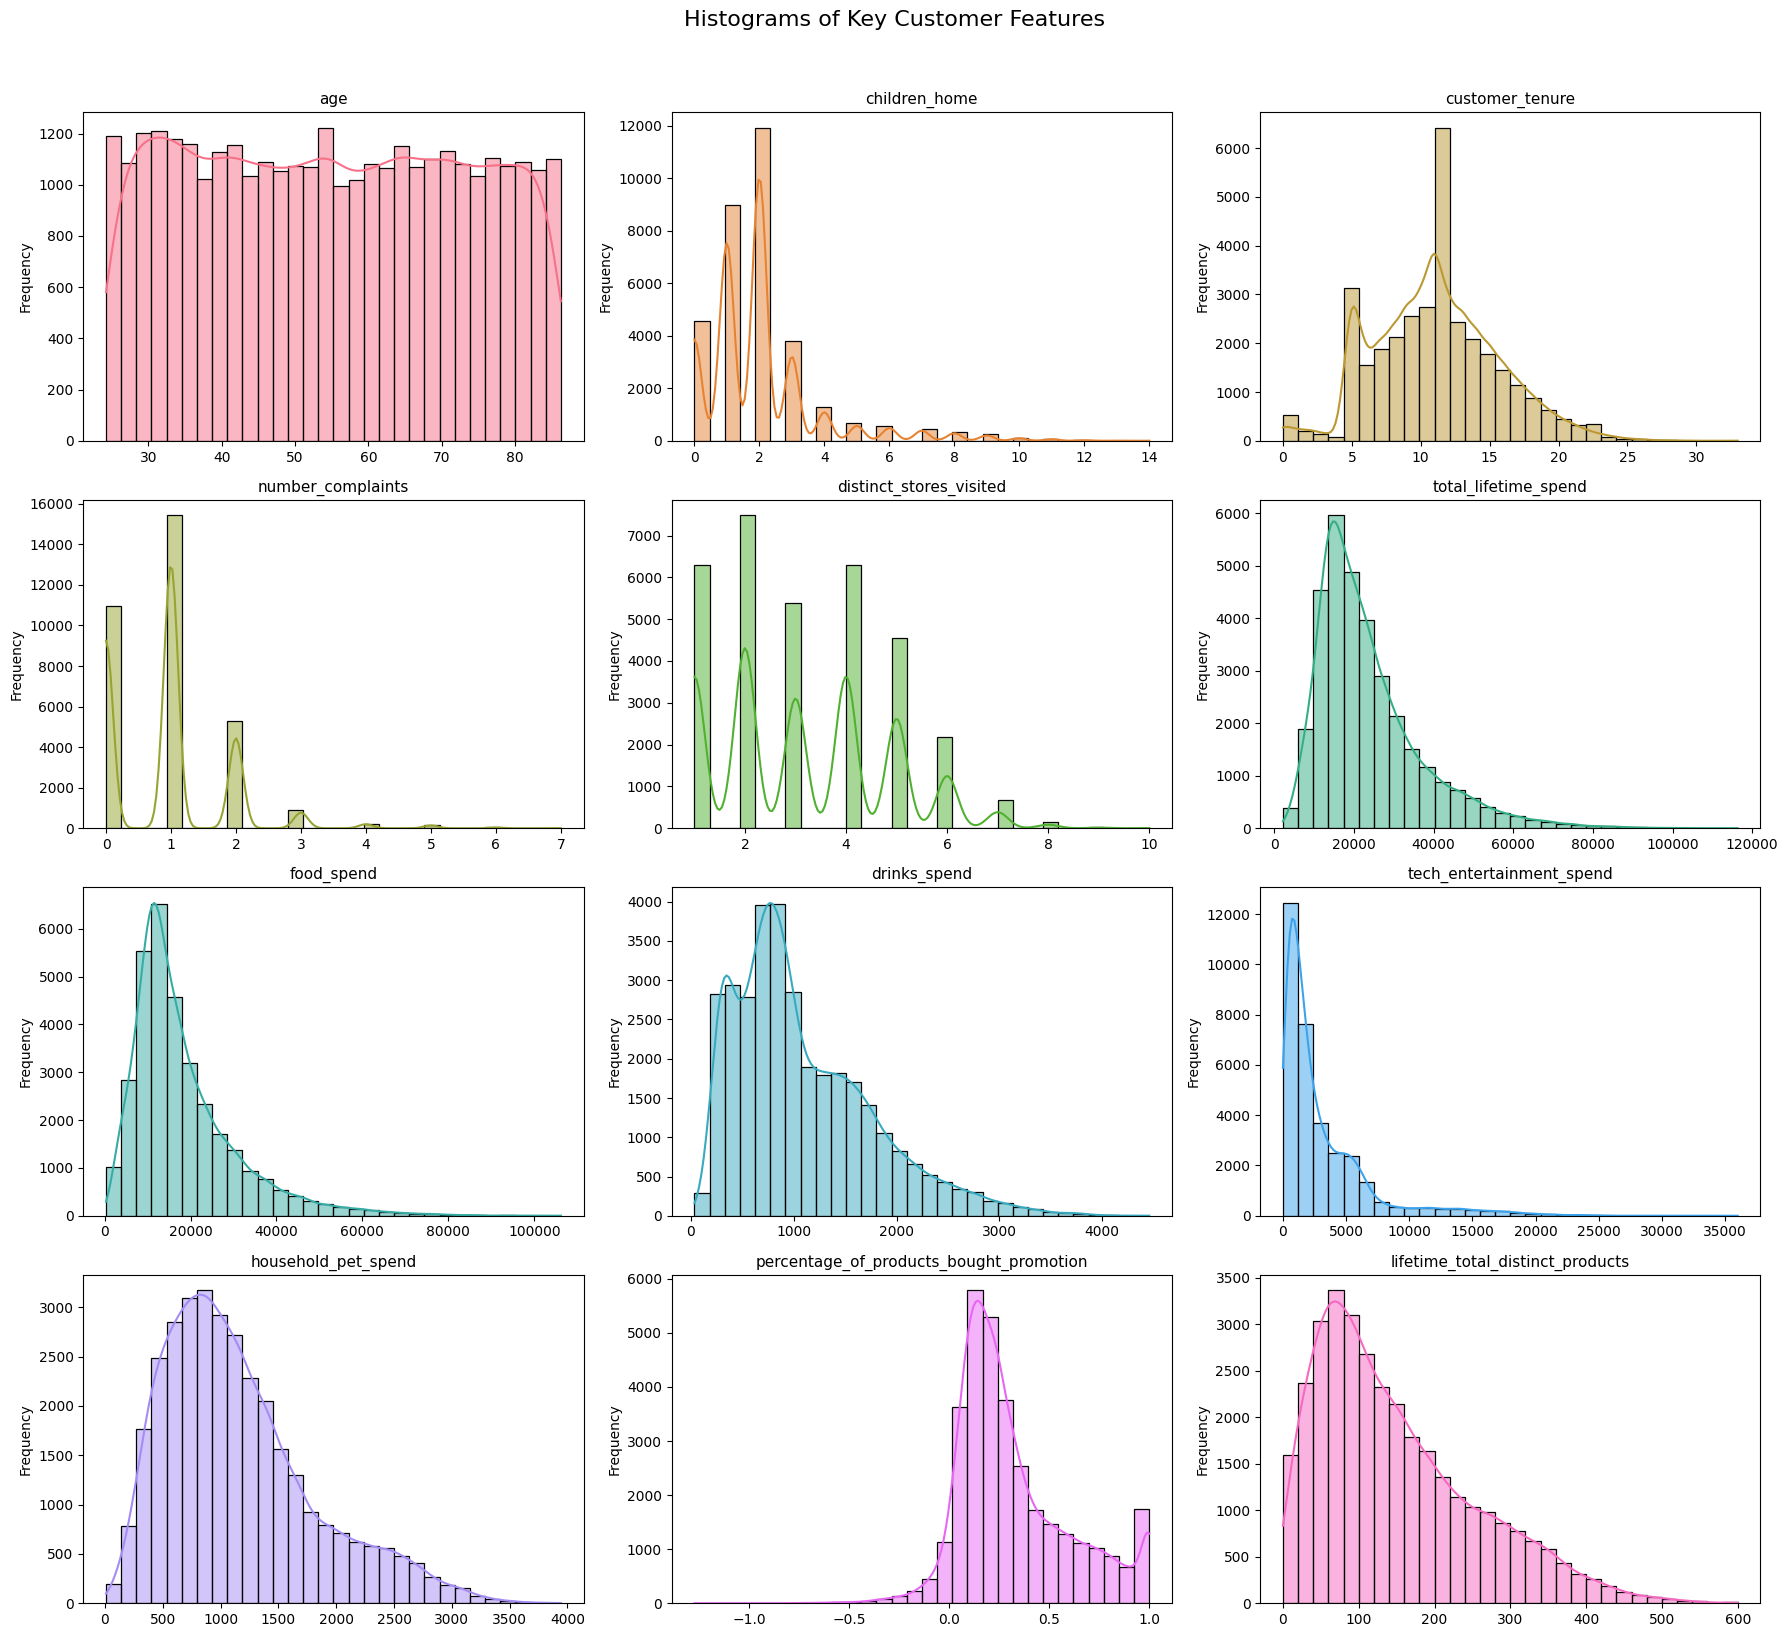

In [59]:
# Step 3.3 — Plot distributions of key customer variables

plot_feature_histograms(clean_df, eda_features)

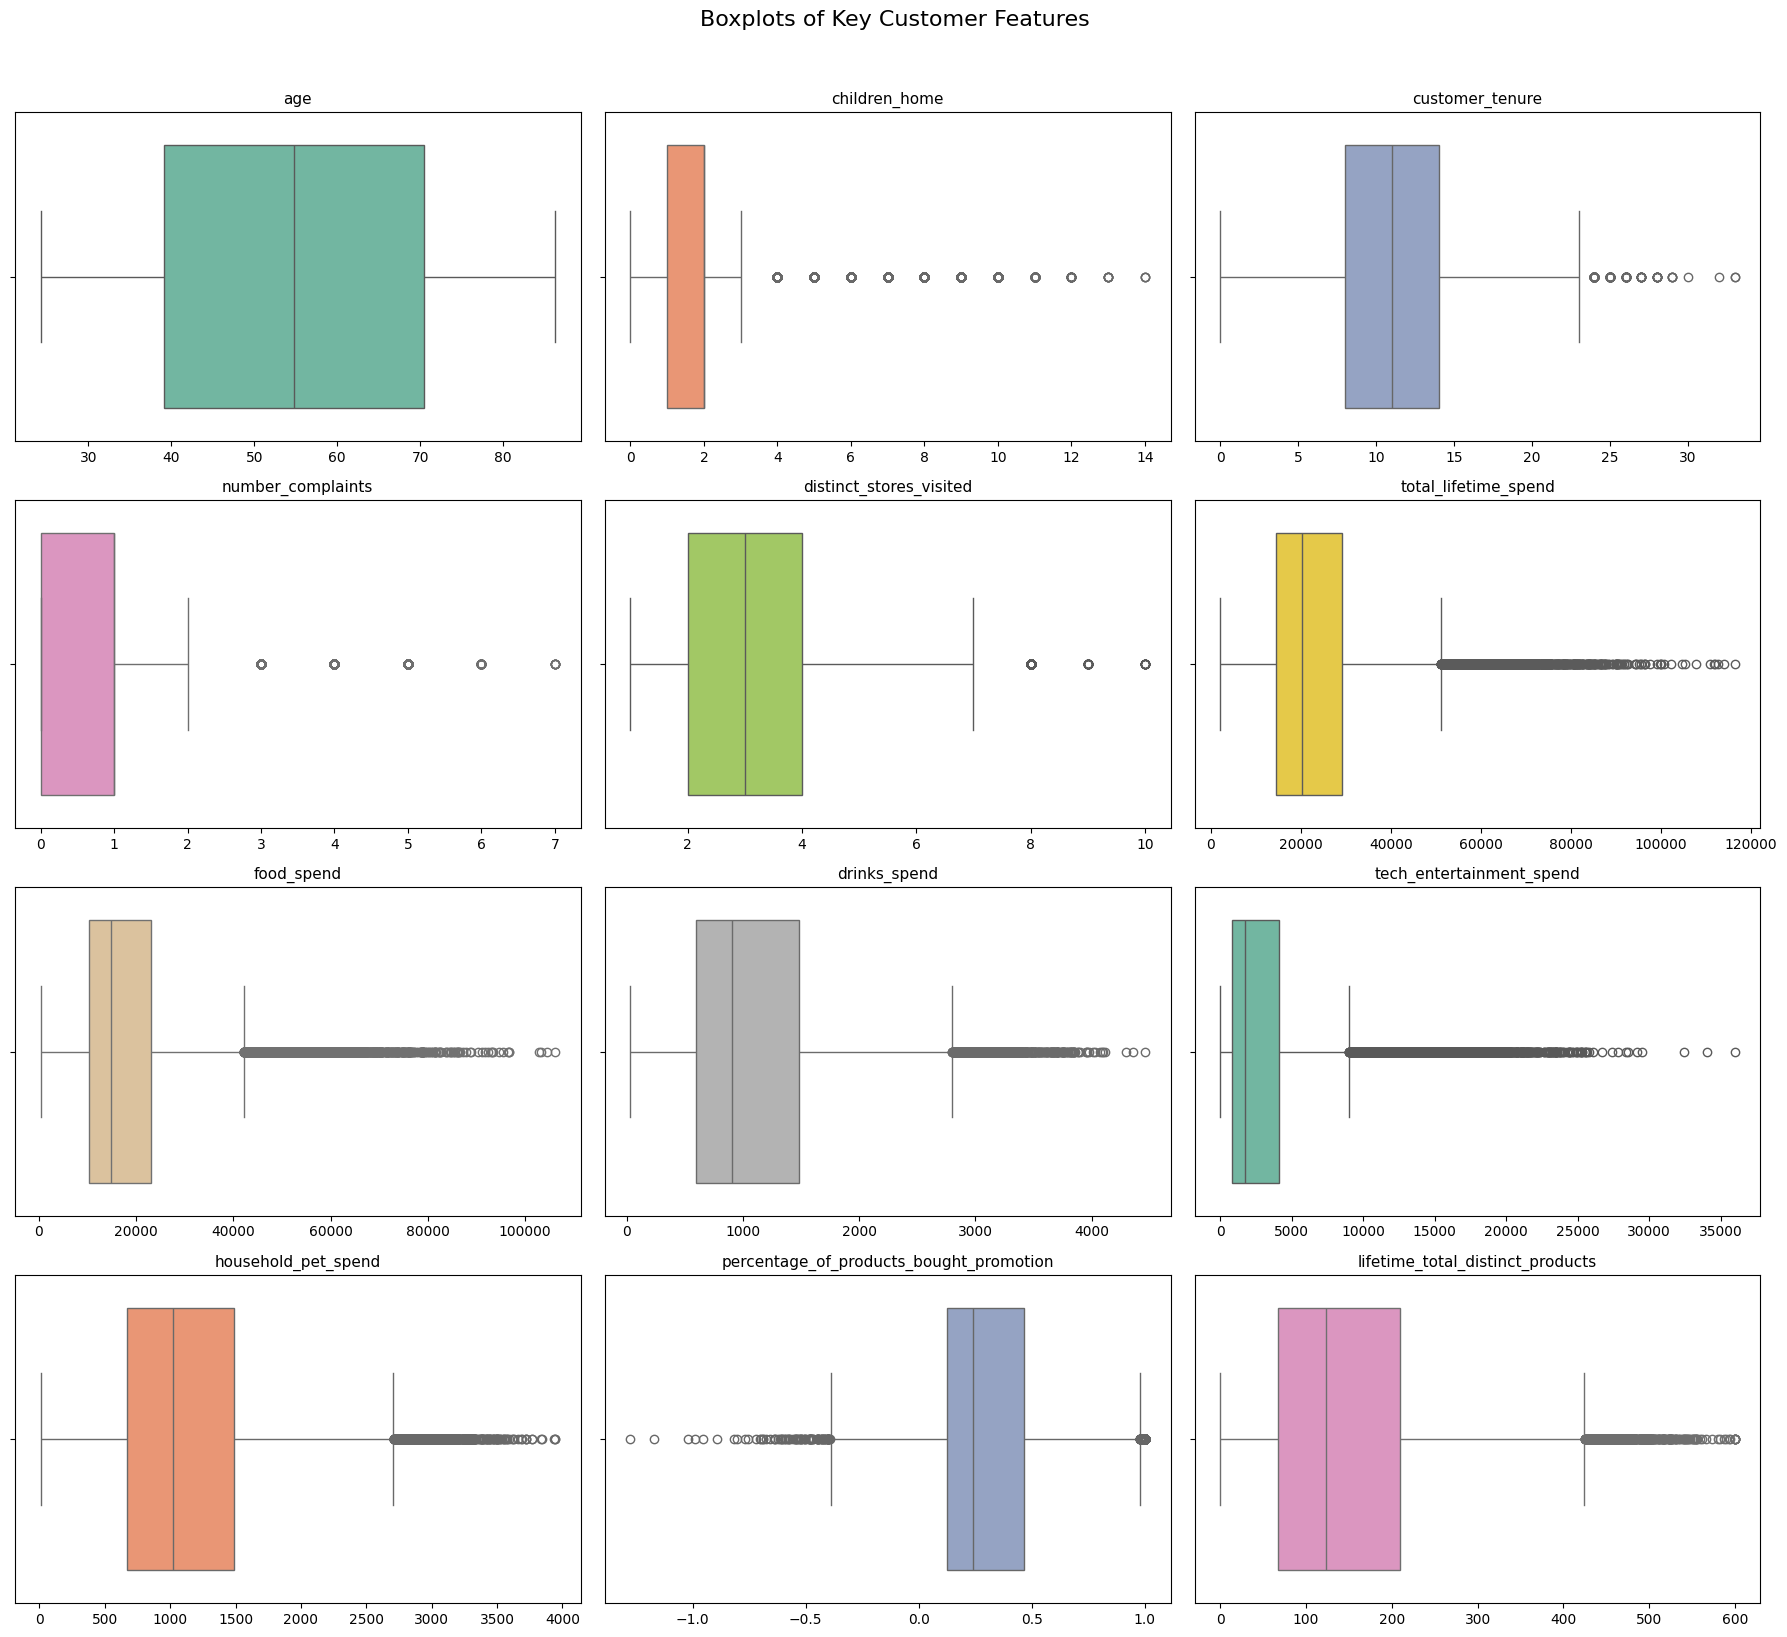

In [60]:
# Step 3.4 — Plot boxplots to inspect potential outliers

plot_feature_boxplots(clean_df, eda_features)

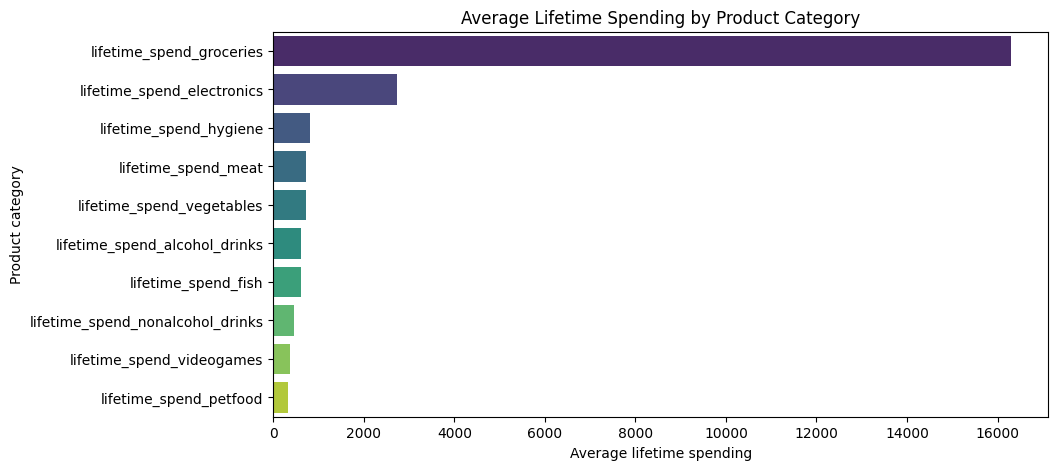

lifetime_spend_groceries            16306.227798
lifetime_spend_electronics           2737.209093
lifetime_spend_hygiene                819.004540
lifetime_spend_meat                   723.827320
lifetime_spend_vegetables             722.097464
lifetime_spend_alcohol_drinks         620.754343
lifetime_spend_fish                   605.848205
lifetime_spend_nonalcohol_drinks      464.352776
lifetime_spend_videogames             370.881803
lifetime_spend_petfood                336.032690
dtype: float64

In [64]:
# Step 3.5 — Average lifetime spending by product category

spending_categories = [
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood"
]

avg_spending = clean_df[spending_categories].mean().sort_values(ascending=False)

avg_spending_df = avg_spending.reset_index()
avg_spending_df.columns = ["product_category", "average_lifetime_spending"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=avg_spending_df,
    x="average_lifetime_spending",
    y="product_category",
    hue="product_category",
    palette="viridis",
    legend=False
)

plt.title("Average Lifetime Spending by Product Category")
plt.xlabel("Average lifetime spending")
plt.ylabel("Product category")
plt.show()

display(avg_spending)

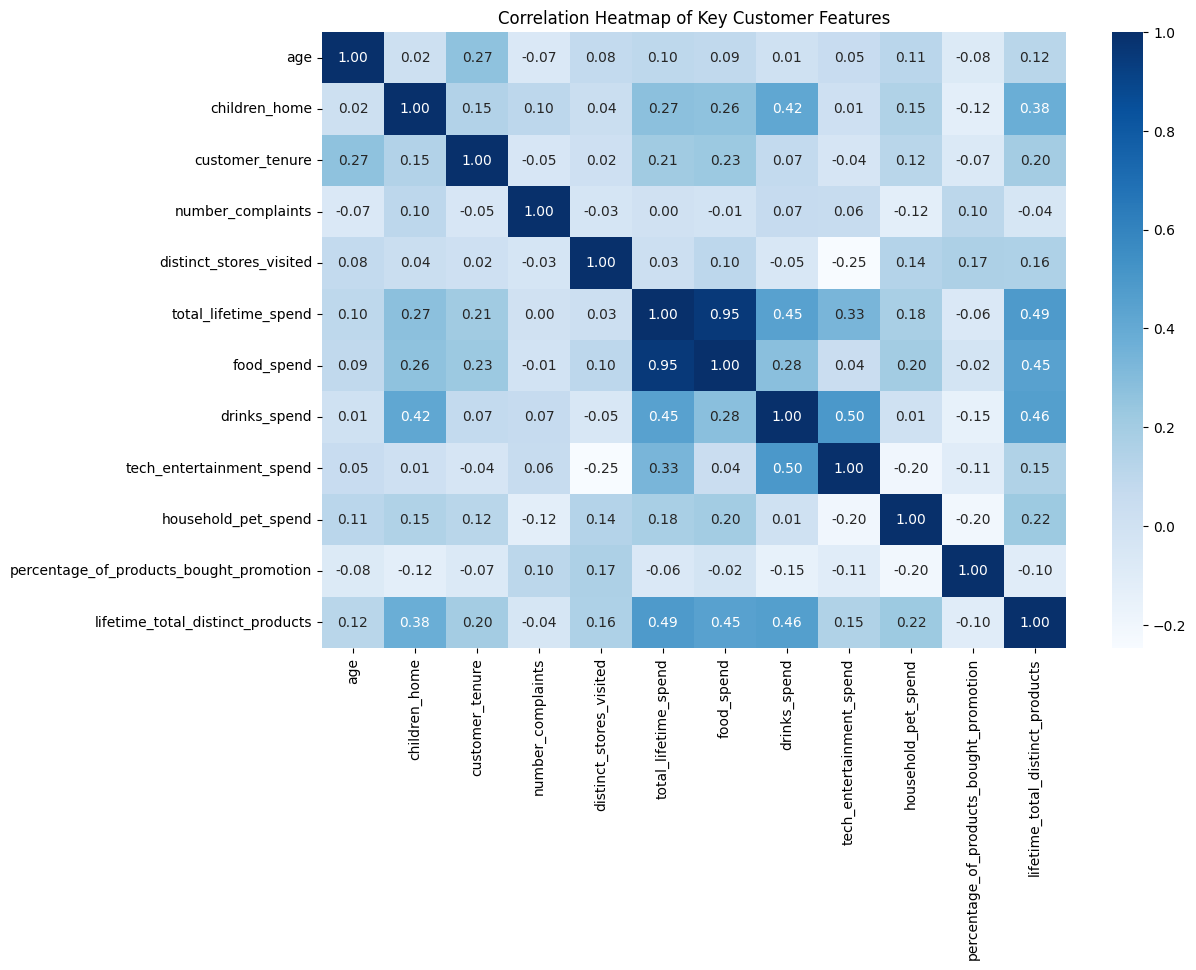

In [62]:
# Step 3.6 — Correlation heatmap of key customer variables

correlation_matrix = clean_df[eda_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Heatmap of Key Customer Features")
plt.show()

In [63]:
# Step 3.7 — Summary table of key EDA findings

summary_table = pd.DataFrame({
    "Metric": [
        "Average age",
        "Average number of children/teens at home",
        "Average customer tenure",
        "Average total lifetime spend",
        "Average promotion purchase percentage",
        "Average number of distinct products",
        "Average number of complaints"
    ],
    "Value": [
        clean_df["age"].mean(),
        clean_df["children_home"].mean(),
        clean_df["customer_tenure"].mean(),
        clean_df["total_lifetime_spend"].mean(),
        clean_df["percentage_of_products_bought_promotion"].mean(),
        clean_df["lifetime_total_distinct_products"].mean(),
        clean_df["number_complaints"].mean()
    ]
})

display(summary_table)

,Metric,Value
0,Average age,54.862188
1,Average number of children/teens at home,2.014862
2,Average customer tenure,11.078637
3,Average total lifetime spend,23706.236031
4,Average promotion purchase percentage,0.318073
5,Average number of distinct products,148.914644
6,Average number of complaints,0.932230


### Step 3.8 — EDA interpretation

The exploratory analysis shows that the customer base is relatively mature, with an average age of approximately 55 years. Customers also tend to have a long relationship with the store, with an average tenure of around 11 years. On average, customers have about two children or teenagers at home, visit around three distinct stores, and have purchased approximately 149 distinct products over their lifetime.

Spending behavior is clearly dominated by groceries. The average lifetime spending on groceries is much higher than any other category, reaching approximately 16,306, while electronics is the second largest category with an average of approximately 2,737. Other categories, such as hygiene, meat, vegetables, alcoholic drinks, fish, non-alcoholic drinks, videogames and pet food, represent much smaller average spending levels. This suggests that groceries are the core category driving customer value, while other categories may help differentiate more specific customer segments.

The histograms and boxplots show that several spending variables are right-skewed and contain visible outliers. This means that most customers spend within a moderate range, while a smaller group of customers spends substantially more. This pattern is especially visible in total lifetime spending, food spending, technology and entertainment spending, and the number of distinct products purchased. Because of this, scaling will be necessary before applying distance-based clustering methods such as K-Means.

The correlation heatmap shows a very strong relationship between total lifetime spending and food spending, with a correlation of approximately 0.95. This indicates that food-related purchases explain a large part of total customer value. Total lifetime spending is also moderately related to the number of distinct products purchased, drinks spending and technology and entertainment spending. This suggests that high-value customers are not only spending more, but may also have broader purchasing behavior across categories.

Finally, the promotion variable appears to have some invalid negative values, which should be corrected before the clustering stage. Since this variable is relevant for understanding promotion sensitivity, it should be cleaned carefully before being used in segmentation.

## 4. Clustering and Segmentation

We use KMeans clustering to segment customers.  
The optimal number of clusters is chosen using:
- Silhouette Score
- Elbow Method (Inertia)

Cluster labels are added back to the dataset.

k=2, silhouette=0.1528, inertia=627372
k=3, silhouette=0.1627, inertia=569035
k=4, silhouette=0.1297, inertia=539789
k=5, silhouette=0.1325, inertia=502620
k=6, silhouette=0.1031, inertia=498593
k=7, silhouette=0.1233, inertia=464495
k=8, silhouette=0.1464, inertia=439376
k=9, silhouette=0.1494, inertia=430771
k=10, silhouette=0.1432, inertia=422962


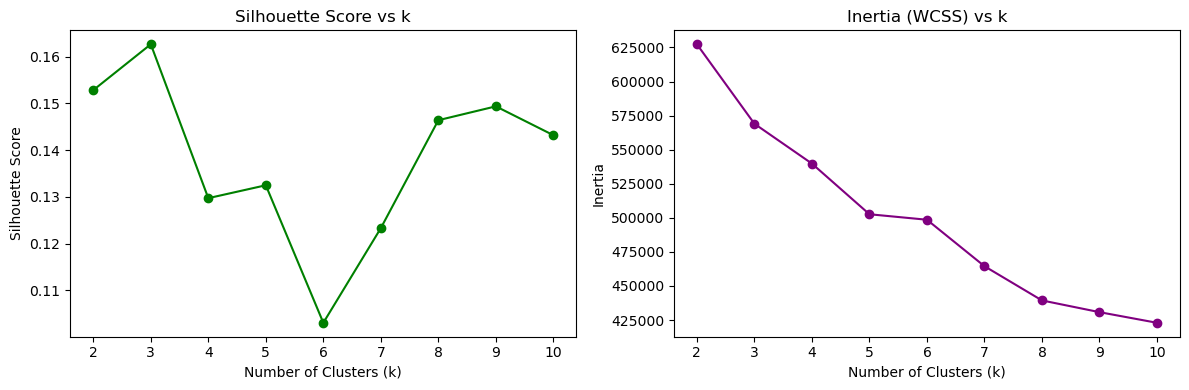

In [ ]:
X = clean_df.select_dtypes(include='number').drop(columns=['customer_id'])
k_range, silhouette_scores, inertia_scores = find_optimal_k(X)
plot_kmeans_scores(k_range, silhouette_scores, inertia_scores)

# Best (k = 3)
labels, model = run_kmeans(X, k=3)
clean_df['cluster'] = labels

## 5. Cluster Profiling

To interpret the clusters, we visualize key features across segments using:
- Pairwise plots 
- Boxplots grouped by cluster
- PCA projection for 2D visualization

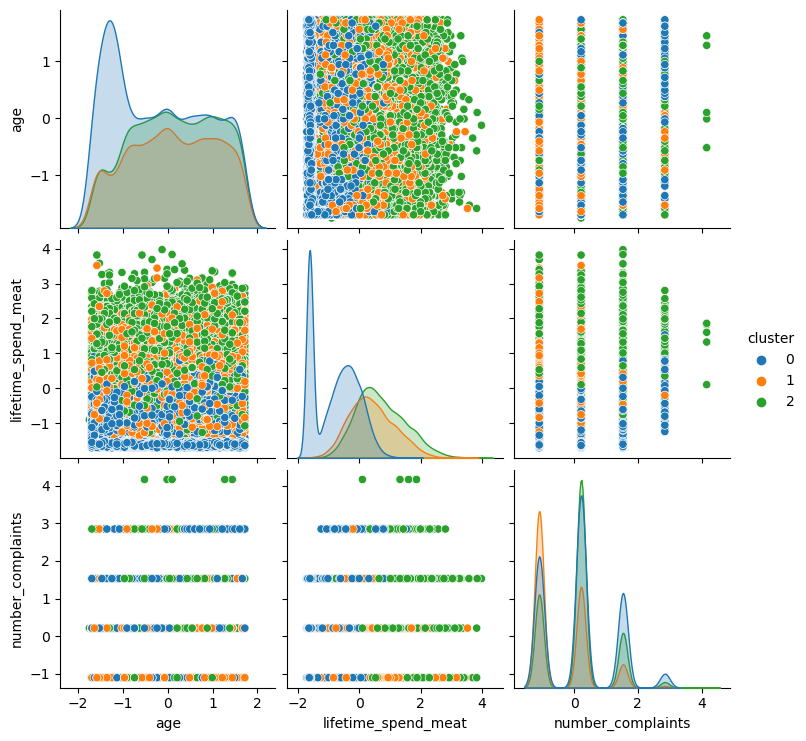

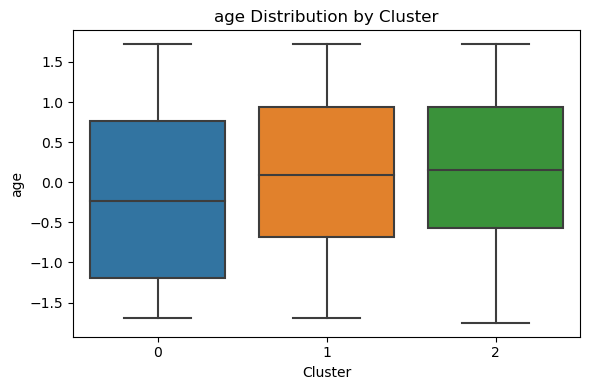

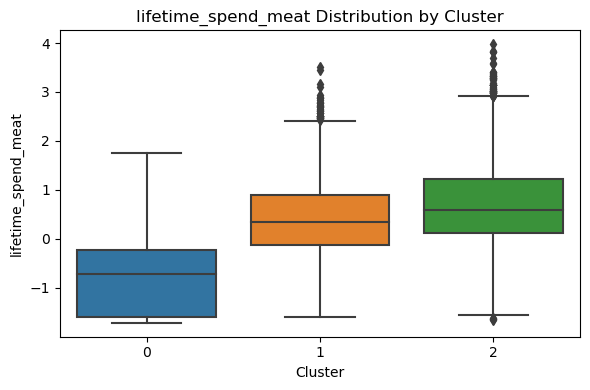

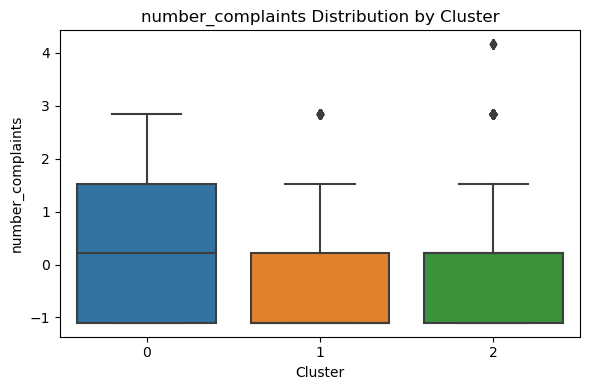

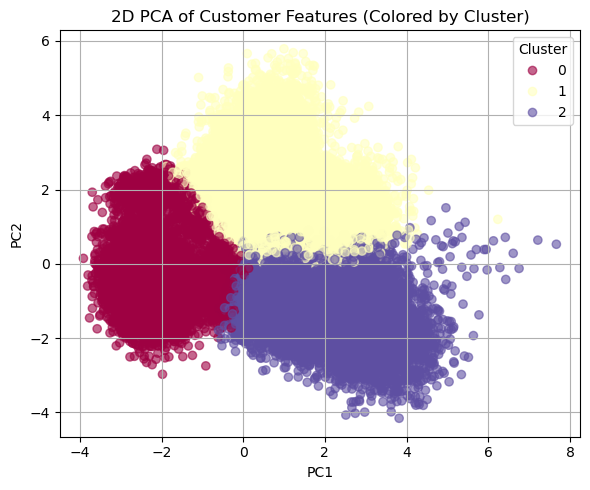

In [ ]:
plot_pairwise(clean_df, ['age', 'lifetime_spend_meat', 'number_complaints'])

# Profiling
for feature in ['age', 'lifetime_spend_meat', 'number_complaints']:
    plot_cluster_feature_boxplot(clean_df, feature)
plot_pca_2d(X, labels)

## 6. Exporting Final Cluster Assignments

We export a `.csv` file containing each `customer_id` and their assigned cluster.  
This allows us to link cluster segments with transactional data in the next step.

In [ ]:
clean_df[['customer_id', 'cluster']].to_csv("final_clusters.csv", index=False)

## 7. Market Basket Analysis

We perform Market Basket Analysis using the Apriori algorithm.  
This identifies frequent itemsets and association rules from customer purchases.  
By merging basket data with the customer clusters, we can tailor insights to each segment.

--- final_clusters ---
   customer_id  cluster
0        29930        2
1         6813        0
2        39451        2
3        21557        1
4        16415        2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34060 entries, 0 to 34059
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  34060 non-null  int64
 1   cluster      34060 non-null  int64
dtypes: int64(2)
memory usage: 532.3 KB
None
        customer_id       cluster
count  34060.000000  34060.000000
mean   20010.854433      0.896829
std    11557.889072      0.851550
min        1.000000      0.000000
25%    10018.750000      0.000000
50%    19985.500000      1.000000
75%    30042.250000      2.000000
max    40000.000000      2.000000
customer_id    0
cluster        0
dtype: int64
--- costumer_basket ---
   invoice_id                                      list_of_goods  customer_id
0     5062209  ['megaman zero 3', 'energy bar', 'pokemon viol... 

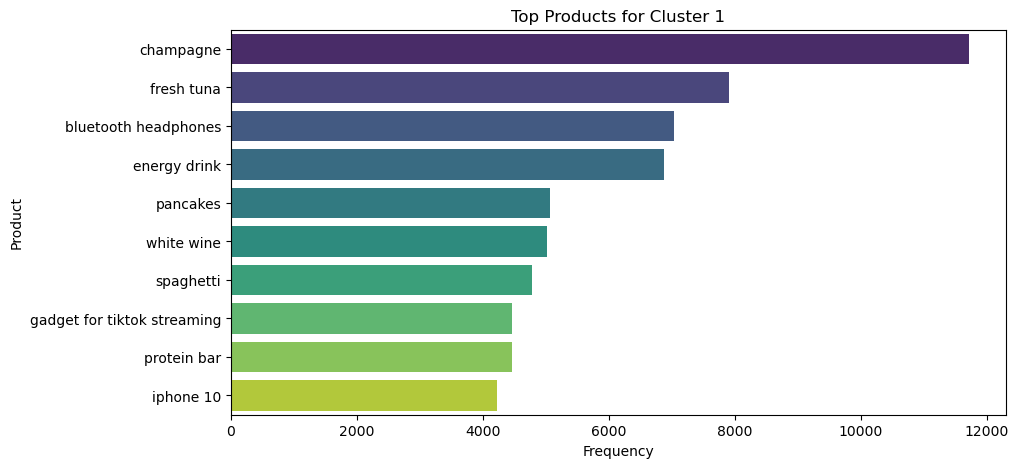

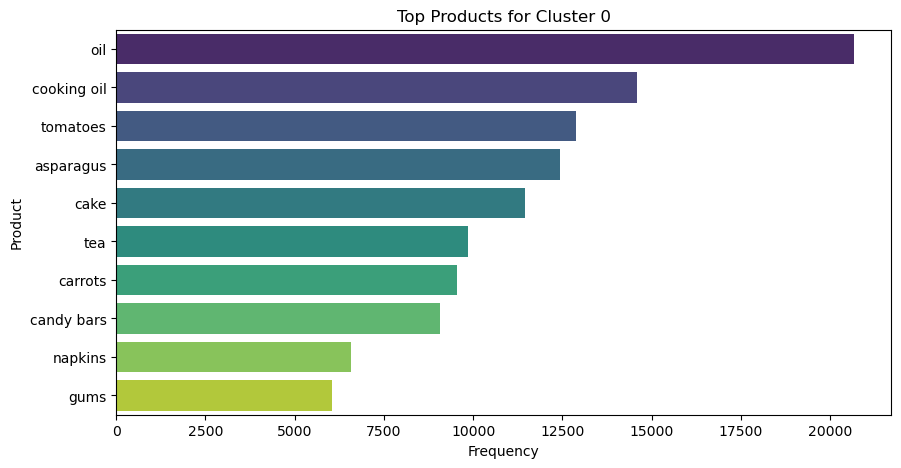

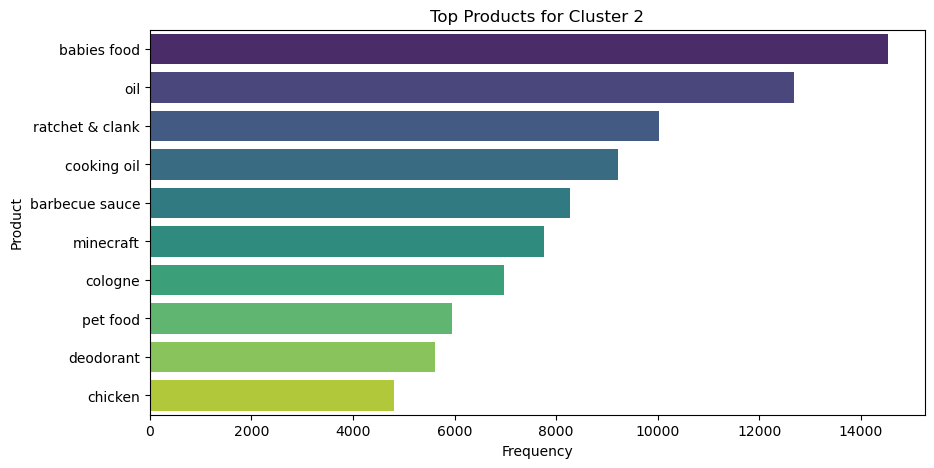


=== Cluster 1 ===
                    antecedents                 consequents   support  \
1705           (cider, bramble)  (white wine, dessert wine)  0.015359   
1822     (red wine, white wine)       (cider, dessert wine)  0.011920   
1465            (beer, bramble)  (white wine, dessert wine)  0.010048   
1482              (cider, beer)  (white wine, dessert wine)  0.020173   
1815       (french wine, cider)  (white wine, dessert wine)  0.012914   
1493          (red wine, cider)          (white wine, beer)  0.010354   
1814  (french wine, white wine)       (cider, dessert wine)  0.012914   
1704      (white wine, bramble)       (cider, dessert wine)  0.015359   
1820          (red wine, cider)  (white wine, dessert wine)  0.011920   
1499        (cider, black beer)  (white wine, dessert wine)  0.010621   

      confidence      lift  
1705    0.424051  5.505507  
1822    0.319018  5.464652  
1465    0.420800  5.463303  
1482    0.418715  5.436237  
1815    0.418317  5.431064  
149

In [ ]:
# Load cluster assignments and basket
final_clusters = pd.read_csv("final_clusters.csv")
customer_basket = pd.read_csv("data/customer_basket.csv")

# Inspect the data
inspect_data(final_clusters, name="final_clusters")
inspect_data(customer_basket, name="costumer_basket")

# Merge 
exploded_basket = merge_explode(customer_basket, final_clusters)
inspect_data(exploded_basket, name="exploded_basket")

basket_analysis(exploded_basket)